In [1]:
import json
import os
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import batch_utils

In [2]:
# Experiment definition
exp_group = 'batch_rxbkg_state1_mech1'
exp_name = 'net_newsec_ee_fade_var_seed'
#exp_group = 'batch_rxbkg_unconn_state1_mech1'
#exp_name = 'net_newsec_var_seed'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name

exp_names_sub = {
    'surr': 'exp_ctx_unconn_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    'full': 'exp_ctx_ee_1_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    'ee_surr': 'exp_ctx_ee_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    'ee_fade': 'exp_ctx_ee_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_unconn': 'exp_thal_unconn_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_ee_surr': 'exp_thal_ee_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'re_tc_surr': 'exp_thal_ire_tc_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_any_tc_surr': 'exp_thal_pe_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_ti_tc_surr': 'exp_thal_ti_tc_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_tc_ti_surr': 'exp_thal_tc_ti_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_tc_ti_fade': 'exp_thal_tc_ti_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_ti_tc_fade': 'exp_thal_ti_tc_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'thal_full': 'exp_thal_ee_1_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'fade_all': 'exp_thal_all_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'core_full': 'exp_core_full_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'matx_full': 'exp_matx_full_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'tim_core_surr': 'exp_tim_core_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'matx_ti_surr': 'exp_matx_ti_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'matx_core_surr': 'exp_matx_core_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_core_surr': 'exp_irem_core_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_ti_surr': 'exp_irem_ti_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_ire_surr': 'exp_irem_ire_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'irem_tc_surr': 'exp_irem_tc_0_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_surr': 'exp_a1_ee_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_irem_ire_surr': 'exp_a1_ee_0_irem_ire_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_fade_irem_ire_surr': 'exp_a1_ee_fade_irem_ire_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_irem_ire_surr': 'exp_a1_irem_ire_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_ee_irem_core_surr': 'exp_a1_ee_0_irem_core_0_nseed_5_t_7.0_10.0_wmult_0.25_ee_0.5',
    #'a1_ee_surr_thal_ictrl': 'net_newsec_ctrl_var_seed/exp_a1_ee_0_nseed_15_t_10.0_15.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_ee_fade_thal_ictrl': 'net_newsec_ctrl_var_seed/exp_a1_ee_fade_nseed_15_t_10.0_15.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_ee_surr': 'net_newsec_ctrl_var_seed/exp_a1_ee_0_ictrl_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_ee_fade': 'net_newsec_ctrl_var_seed/exp_a1_ee_fade_ictrl_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
    #'a1_full_thal_ictrl': 'net_newsec_ctrl_var_seed/exp_a1_full_nseed_15_t_10.0_15.0_ictrl_wmult_0.25_ee_0.5',
    #'a1_full': 'net_newsec_ctrl_var_seed/exp_a1_ee_full_ictrl_0_nseed_15_t_10.0_15.0_wmult_0.25_ee_0.5',
}

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

pop_names = df.index.tolist()

In [3]:
R_all = {}

for exp_label, exp_name_sub in exp_names_sub.items():
    # Find json files with sim esults
    parts = exp_name_sub.split('/')
    dirpath_res_base = dirpath_res.parent if len(parts) == 2 else dirpath_res
    dirpath_data = dirpath_res_base / exp_name_sub / 'results'
    json_files = sorted(dirpath_data.glob('*.json'))
    n_trials = len(json_files)

    # Extract population rates from json files
    R = np.full((len(pop_names), n_trials), np.nan)
    for i, fpath in enumerate(json_files):
        with open(fpath, 'r') as fid:
            res = json.load(fid)
        for j, pop in enumerate(pop_names):
            R[j, i] = res['rates'].get(pop, np.nan)

    R = xr.DataArray(
        R,
        dims=['pop', 'trial'],
        coords={'pop': pop_names, 'trial': np.arange(n_trials)}
    )

    # Drop populations that have no valid rate in any trial
    R_all[exp_label] = R.sel(pop=~R.isnull().all(dim='trial'))


#### Plot rate distr. across seeds (multiple exp. setups, group by pop.)

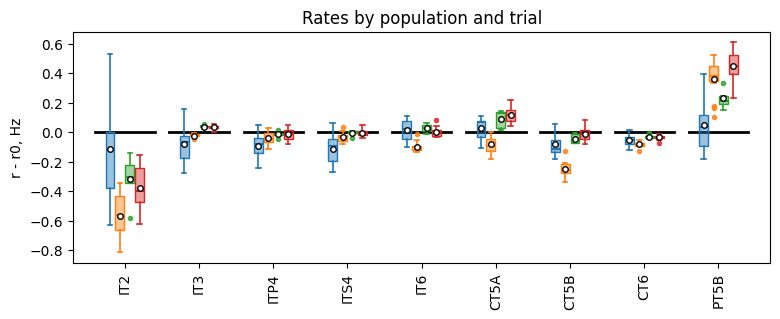

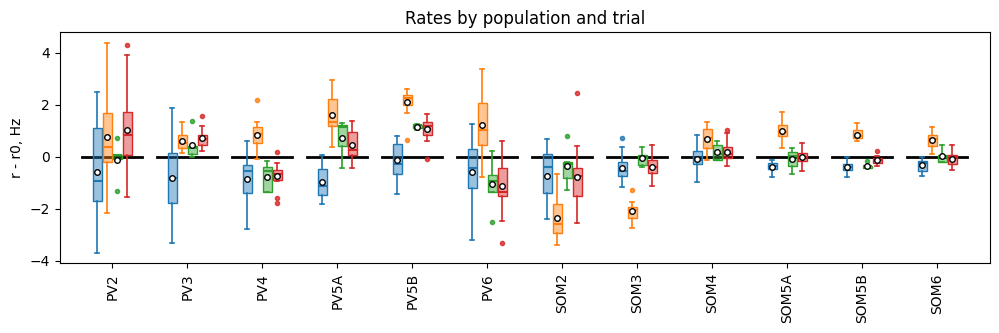

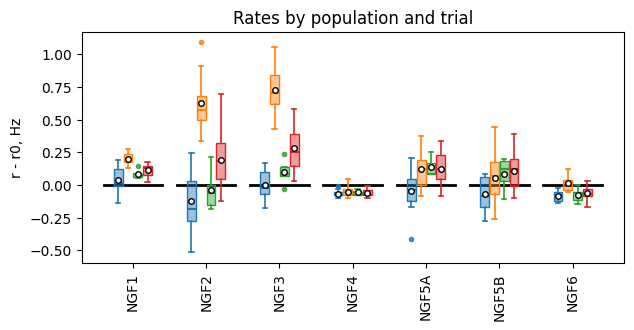

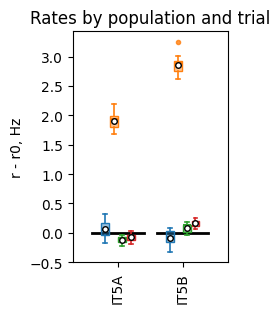

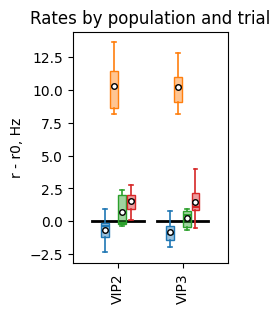

In [11]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
VIP23_POPS = ['VIP2', 'VIP3']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

THAL_E_POPS = ['TC', 'HTC', 'TCM']
THAL_I_POPS = ['TI', 'TIM', 'IRE', 'IREM']
CORE_POPS = ['TC', 'HTC', 'TI', 'IRE']
MATX_POPS = ['TCM', 'TIM', 'IREM']
#THAL_POPS = THAL_E_POPS + THAL_I_POPS
THAL_POPS = CORE_POPS + MATX_POPS

groups_vis = [
    #PYR_POPS,
    #PV_POPS + VIP23_POPS,
    #SOM_POPS + NGF_POPS
    ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT6', 'CT5A', 'CT5B', 'CT6', 'PT5B'],
    PV_POPS + SOM_POPS,
    NGF_POPS,
    ['IT5A', 'IT5B'],
    VIP23_POPS
]

def plot_rates(
        pops_vis,
        exp_labels=None,
        figsize=(10, 3),
        box_w=0.12, d=0.2,
        target_alpha=1, box_alpha=0.8, 
        normalize=False, center=False,
        legend=True, title=True, ylabel=True
        ):
    fig, ax = plt.subplots(figsize=figsize)

    if center and normalize:
        raise ValueError("Cannot center and normalize simultaneously.")

    exp_labels = exp_labels or list(R_all.keys())
    x_base = np.arange(len(pops_vis))
    colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))

    exp_labels = [l for l in exp_labels if l is not None]
    offsets = np.linspace(-d, d, len(exp_labels))

    # Target horizontal markers
    d1 = d * 2
    for ix, pop in enumerate(pops_vis):
        if center: target = 0
        elif normalize: target = 1
        else: target = df.loc[pop, 'target_rate']
        ax.plot([x_base[ix] - d1, x_base[ix] + d1], [target, target],
                color='black', linewidth=2, linestyle='-', zorder=0, alpha=target_alpha)

    # Grouped boxplots
    box_props = lambda c: dict(
        patch_artist=True, showmeans=True, meanline=False, whis=1.5, vert=True,
        boxprops=dict(facecolor=(*c, 0.45), edgecolor=c),
        medianprops=dict(color=c, linewidth=1.5),
        whiskerprops=dict(color=c, linewidth=1.2),
        capprops=dict(color=c, linewidth=1.2),
        meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=4),
        flierprops=dict(marker='.', markerfacecolor=c, markeredgecolor=c, alpha=box_alpha),
    )

    for offset, exp_label in zip(offsets, exp_labels):
        if exp_label is None:
            continue
        R_exp = R_all[exp_label].reindex(pop=pops_vis)
        data = [R_exp.sel(pop=pop).values for pop in pops_vis]
        data = [y[~np.isnan(y)] for y in data]
        positions = [x_base[ix] + offset for ix, y in enumerate(data) if len(y) > 0]
        data_valid = np.asarray([y for y in data if len(y) > 0])
        if center:
            data_valid = [y - df.loc[pop, 'target_rate']
                          for pop, y in zip(pops_vis, data) if len(y) > 0]
        elif normalize:
            data_valid = [y / df.loc[pop, 'target_rate']
                          for pop, y in zip(pops_vis, data) if len(y) > 0]
        else:
            data_valid = [y for y in data if len(y) > 0]
        
        try:
            ax.boxplot(data_valid, positions=positions, widths=box_w,
                    **box_props(colors[exp_label]))
        except:
            pass

    # Simple legend
    if legend:
        handles = [plt.Line2D([0], [0], color=colors[k], lw=6, alpha=box_alpha, label=k) for k in exp_labels]
        ax.legend(handles=handles)

    ax.set_xticks(x_base)
    ax.set_xticklabels(pops_vis, rotation=90)
    if ylabel:
        if center: ax.set_ylabel('r - r0, Hz')
        elif normalize: ax.set_ylabel('r / r0')
        else: ax.set_ylabel('Rate, Hz')
    if title:
        ax.set_title('Rates by population and trial')

for group in groups_vis:
    w = len(group)
    plot_rates(group, center=True, figsize=(w, 3), legend=0)

KeyError: 'fade'

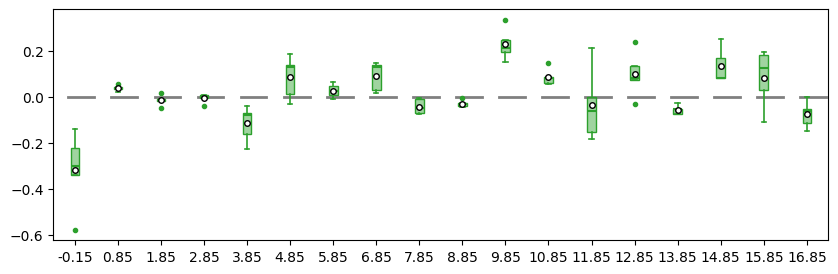

In [5]:
#exp_labels=['ee_surr', 'full']
#exp_labels=['unconn', 'full']
#exp_labels=['unconn', None, 'ee_surr']
#exp_labels=['unconn', None, 'ee_surr', 'fade']
#exp_labels=[None, 'full', None, 'fade']
exp_labels=[None, None, 'ee_surr', 'fade']

par = {'figsize': (10, 3), 'target_alpha': 0.5,
       'box_w': 0.2, 'box_alpha': 1, 'd': 0.15,
       'normalize': 0, 'center': 1, 'legend': 0,
       'title': 0, 'ylabel': 0}

#plot_rates(PYR_POPS + NGF_POPS + VIP_POPS, exp_labels, **par)
plot_rates(PYR_POPS + NGF_POPS, exp_labels, **par)
plot_rates(PV_POPS + SOM_POPS + NGF_POPS, exp_labels, **par)
plot_rates(PYR_POPS + NGF_POPS + VIP_POPS, exp_labels, **par)
#plot_rates(VIP_POPS, exp_labels, **par)
#plot_rates(NGF_POPS, exp_labels, **par)

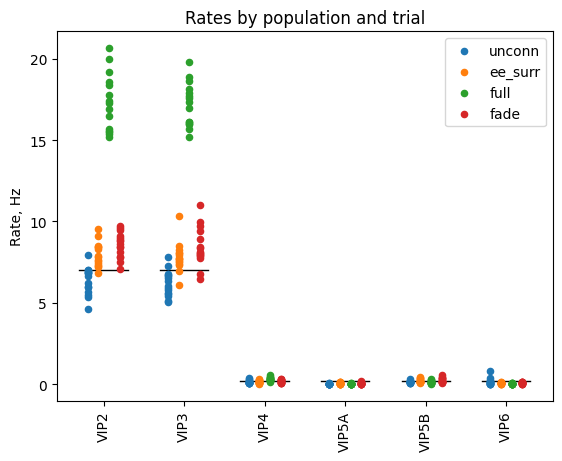

In [ ]:
#pops_vis = ['IT2', 'IT3', 'PV2', 'PV3', 'SOM2', 'SOM3']
pops_vis = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']

d = 0.2
s = 20

#fig, ax = plt.subplots(figsize=(18, 6))
fig, ax = plt.subplots()

exp_labels = list(R_all.keys())
x_base = np.arange(len(pops_vis))
offsets = np.linspace(-d, d, len(exp_labels))
colors = dict(zip(exp_labels, plt.cm.tab10.colors[:len(exp_labels)]))

for ix, pop in enumerate(pops_vis):
    target = df.loc[pop, 'target_rate']
    d1 = d * 1.5
    ax.plot([x_base[ix] - d1, x_base[ix] + d1], [target, target],
            color='black', linewidth=1, linestyle='-', zorder=0)

for offset, exp_label in zip(offsets, exp_labels):
    R_exp = R_all[exp_label].reindex(pop=pops_vis)

    for ix, pop in enumerate(pops_vis):
        y = R_exp.sel(pop=pop).values
        y = y[~np.isnan(y)]
        if len(y) == 0:
            continue

        x = np.full(len(y), x_base[ix] + offset)
        ax.scatter(x, y, s=s, alpha=1, color=colors[exp_label],
                   label=exp_label if ix == 0 else None)

ax.set_xticks(x_base)
ax.set_xticklabels(pops_vis, rotation=90)
#ax.set_xlabel('pop')
ax.set_ylabel('Rate, Hz')
ax.set_title('Rates by population and trial')
ax.legend()   #title='exp_label')
#ax.grid(axis='y', alpha=0.3)
#plt.tight_layout()

#### Plot rate dynamics

In [ ]:
import pickle
from analysis.ou_tuning import sim_res_proc_utils as proc

fpath_data = Path('/ddn/niknovikov19/repo/A1_OUinp/exp_results/batch_rxbkg_state1_mech1/net_newsec_ee_fade_var_seed'
                  #'/exp_ctx_unconn_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5/pkl/data_00001_seed_1001.pkl')
                  '/exp_ctx_ee_fade_nseed_15_t_7.0_10.0_wmult_0.25_ee_0.5/pkl/data_00000_seed_1000.pkl')
with open(fpath_data, 'rb') as fid:
    sim_res = pickle.load(fid)

--No graphics will be displayed.


numprocs=1


(0.7, 3.7)

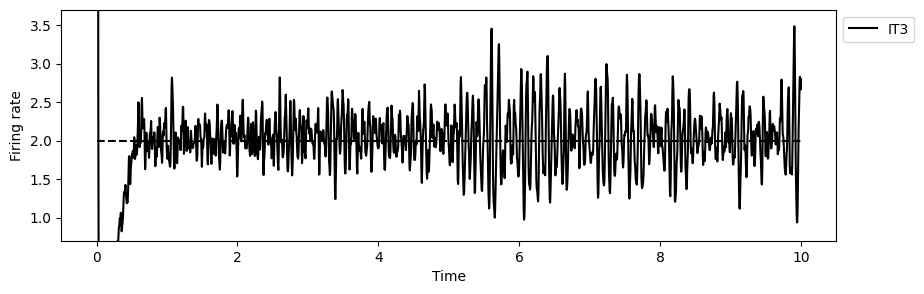

In [ ]:
pop = 'IT3'

# Compute rate dynamics
r_data = proc.calc_rate_dynamics(
    sim_res, t_limits=(0, None), tau_smooth=0.005, pops_used=[pop])

plt.figure(figsize=(10, 3))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

tt, rr = r_data[pop]
r0 = sim_res['simConfig']['target_rates'][pop]
col = 'k'  #colors[0]
plt.plot(tt, rr, label=pop, color=col)
plt.plot([tt[0], tt[-1]], [r0, r0], '--', color=col)

plt.xlabel('Time')
plt.ylabel('Firing rate')
plt.legend(bbox_to_anchor=(1, 1))
plt.ylim([0.7, 3.7])